In [4]:
import pandas as pd
import numpy as np
import regex as re
import matplotlib.pyplot as plt

In [62]:
# party affiliation of U.S. presidents (in pres_df)  <- done
# number of executive orders signed by U.S. presidents  <- done
executive_orders = pd.read_csv("executive_orders.csv")
# Highest military rank held by U.S. presidents (in pres_df) <- done
# Previous roles and professions of U.S. presidents (in pres_df) <- done
# Number of children of U.S. presidents (in pres_df) <- done
# Length of presidential terms (in pres_df)
# Length of inagural addresses of U.S. presidents

In [7]:
df = pd.read_csv("presidents.csv")

# so i can see the full df
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

df.head()

,No.,Name,Birthplace,Birthday,Life,Height,Children,Religion,Higher Education,Occupation,Military Service,Term,Party,Vice President,Previous Office,Economy,Foreign Affairs,Military Activity,Other Events,Legacy
0,1,George Washington,"Pope's Creek, VA",22-Feb,1732-1799,1.88,0,Episcopalian,NaN,"Plantation Owner, Soldier",Commander-in-Chief of the Continental Army in the Revolutionary War,1789-1797,"None, Federalist",John Adams,Commander-in-Chief,"[' Hamilton established BUS', '1792 Coinage Act', '1792 New York Stock Exchange organized.', '1791 Bank Act: banking...","['1793 Neutrality in the France-Britain conflict', '1795 Jay Treaty with Britain. British forces withdrew', ""1795 Pi...",['1794 Whiskey Rebellion'],"['1791 Bill of Rights', '1792 Post Office founded.', '1792, 1796 Kentucky & Tennessee joined the Union']","He is universally regarded as one of the greatest figures in U.S. history. “First in war, first in peace, and first ..."
1,2,John Adams,"Braintree, MA",30-Oct,1735-1826,1.70,5,Unitarian,Harvard,"Lawyer, Farmer",none,1797-1801,Federalist,Thomas Jefferson,1st Vice President of USA,['1798 Progressive land value tax of up to 1% of the value of a property'],['1797 the XYZ Affair: a bribe of French agents leaked'],['1798–1800 The Quasi war. Undeclared naval war with France'],"['1798 Alien & Sedition Act to silence critics; unpopular', '1800 Capital relocated to Washington DC', '1801 Nominat...",One of the most experienced men ever to become President. Played a major role in the movement for independence. By t...
2,3,Thomas Jefferson,"Goochland County, VA",13-Apr,1743-1826,1.89,6,unaffiliated Christian,College of William and Mary,"Inventor,Lawyer, Architect",Colonel of Virginia militia (without real military service),1801-1809,Democratic-Republican,"Aaron Burr, George Clinton",2nd Vice President of USA,"['1807 Embargo Act forbidding foreign trade in war', ' Canceled Whiskey Tax.', '1809 Non-Intercourse Act repealing ...",['1805 Peace Treaty with Tripoli. Piracy stopped.'],['1801-05 Naval operation against Tripoli and Barbary pirates'],"['1803 The Louisiana purchase', '1804 12th Amendment changed Presidential election', '1804-06 Authorized Louis & Cla...","Probably the most intelligent man ever to occupy the White House. Of broad interests and activity, he exerted an im..."
3,4,James Madison,"Port Conway, VA",16-Mar,1751-1836,1.63,0,Episcopalian,Princeton,"Plantation Owner, Lawyer",Colonel of Virginia militia (without real military service),1809-1817,Democratic-Republican,"George Clinton, Elbridge Gerry",Secretary of State,"[' The first U.S. protective tariff was imposed', ' Second Bank of the United States established']",['1814 The Treaty of Ghent ends the War of 1812'],"['1811 Tippecanoe battle (Harrison vs. Chief Tecumseh)', '1812-15 War of 1812 with the British. Disastrous.', '1815 ...","['1811 Cumberland Road construction starts (first National Road)', '1817 Veto on Bonus Bill for funding States imp...","His leadership in the War of 1812 was particularly inept. But the young nation emerged united and strong, and Madis..."
4,5,James Monroe,"Monroe Hall, VA",28-Apr,1758-1831,1.83,2,Episcopalian,College of William and Mary,"Plantation Owner, Lawyer",Major of the Continental Army,1817-1825,Democratic-Republican,Daniel Tompkins,Secretary of War,['1819 Panic of 1819 (too much land speculation)'],"['1823 Monroe Doctrine', '1818 49th parallel set as the border with Canada.', '1818 Russo-American Treaty: Russia ou...",['1817 1st Seminole war against Seminole Indians in Florida. Jackson in action.'],"['1819 Florida ceded to US', ""1820 Missouri Compromise Slavery forbidden abv 36° 30'"", '1820 In the election he rece...",His presidency contributed to national defense and security. The Monroe Doctrine became a landmark in American forei...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No.                47 non-null     int64  
 1   Name               47 non-null     object 
 2   Birthplace         47 non-null     object 
 3   Birthday           47 non-null     object 
 4   Life               47 non-null     object 
 5   Height             47 non-null     float64
 6   Children           47 non-null     int64  
 7   Religion           47 non-null     object 
 8   Higher Education   37 non-null     object 
 9   Occupation         47 non-null     object 
 10  Military Service   47 non-null     object 
 11  Term               47 non-null     object 
 12  Party              47 non-null     object 
 13  Vice President     47 non-null     object 
 14  Previous Office    47 non-null     object 
 15  Economy            46 non-null     object 
 16  Foreign Affairs    46 non-nu

In [51]:
df.describe()

,No.,Height,Children,term_start,term_end
count,47.000000,47.000000,47.000000,47.000000,47.000000
mean,24.000000,1.801277,3.148936,1903.085106,1908.106383
std,13.711309,0.069489,2.063963,67.180105,67.287260
min,1.000000,1.630000,0.000000,1789.000000,1797.000000
25%,12.500000,1.750000,2.000000,1849.500000,1851.500000
50%,24.000000,1.800000,3.000000,1893.000000,1897.000000
75%,35.500000,1.850000,5.000000,1962.000000,1966.000000
max,47.000000,1.930000,8.000000,2025.000000,2025.000000


In [9]:
# adding a bool column for college+
df["has_higher_education"] = (
    df["Higher Education"].notna()
    & (df["Higher Education"].astype(str).str.strip() != "")
)

In [10]:
# to make groups based on what their previous office held was
def group_previous_office(text):
    text = str(text).lower().strip()
    if "vice president" in text:
        return "Vice President"
    if "governor" in text:
        return "Governor"
    if "senator" in text or "congressman" in text:
        return "Legislative"
    if "secretary" in text or "minister" in text:
        return "Cabinet"
    if "chief justice" in text or "judge" in text:
        return "Judicial"
    if "general" in text or "commander" in text or "army" in text:
        return "Military Leadership"
    if "president of usa" in text:
        return "Former President"
    if text == "none":
        return "No Major Prior Office Listed"
    return "Other"

df["previous_office_group"] = df["Previous Office"].apply(group_previous_office)

In [16]:
# to get starting and ending year for era definitions
def parse_term(term):
    years = re.findall(r"\d{4}", str(term))
    if len(years) == 0:
      return None, None
    if len(years) == 1:
        return int(years[0]), int(years[0])
    return int(years[0]), int(years[1])

df[["term_start", "term_end"]] = df["Term"].apply(parse_term).apply(pd.Series)

In [19]:
# 1789-now

In [25]:
# trying to define presidential eras based on war

# Founding generation: 1789–1816 # revolution/founding
# Civil War generation: 1817–1876 # union and civil war
# Between Civil War and World War I: 1877–1916 # industrial expansion
# World Wars generation: 1917–1945 # world wars
# Cold War generation: 1946–1991 # cold war command
# War on Terror: 1992–present # modern day

def assign_era(term_start):
    if pd.isna(term_start):
        return None
    elif 1789 <= term_start <= 1816:
        return "Founding Generation"
    elif 1817 <= term_start <= 1876:
        return "Civil War"
    elif 1877 <= term_start <= 1916:
        return "Industrial Expansion"
    elif 1917 <= term_start <= 1945:
        return "World Wars"
    elif 1946 <= term_start <= 1991:
        return "Cold War"
    elif term_start >= 1992:
        return "Modern Day"
    else:
        return "Pre-presidency era"

df["era"] = df["term_start"].apply(assign_era)


In [26]:
df['era'].value_counts()

,count
era,
Civil War,14
Industrial Expansion,10
Cold War,8
Modern Day,6
World Wars,5
Founding Generation,4


In [27]:
df["has_military_service"] = ~df["Military Service"].str.contains(
    "none", case=False, na=False
)

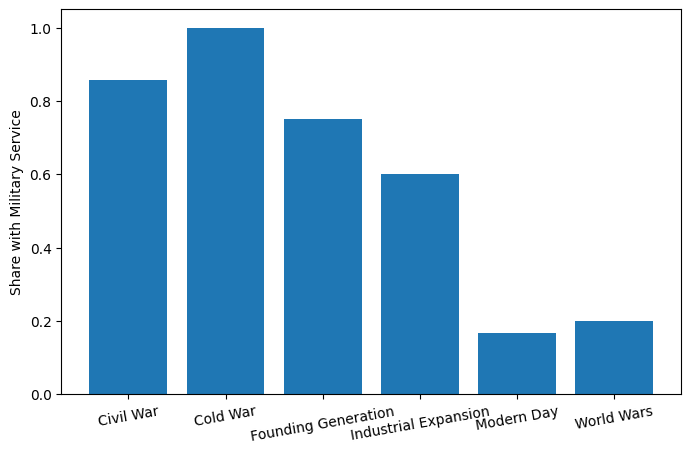

In [28]:
plt.figure(figsize=(8, 5))
military_share = df.groupby("era", observed=False)["has_military_service"].mean()
plt.bar(military_share.index.astype(str), military_share.values)
plt.ylabel("Share with Military Service")
plt.xticks(rotation=10)
plt.show()

In [30]:
# trying to now order the eras correctly

era_order = [
    "Founding Generation",
    "Civil War",
    "Industrial Expansion",
    "World Wars",
    "Cold War",
    "Modern Day"
]

df["era"] = pd.Categorical(df["era"], categories=era_order, ordered=True)


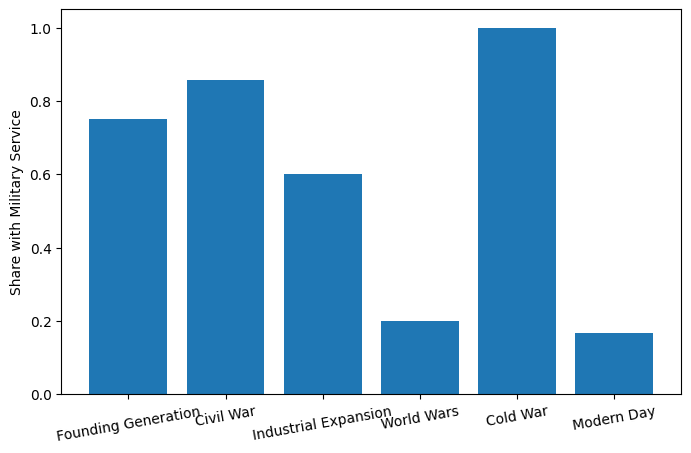

In [31]:
plt.figure(figsize=(8, 5))
military_share = df.groupby("era", observed=False)["has_military_service"].mean()
plt.bar(military_share.index.astype(str), military_share.values)
plt.ylabel("Share with Military Service")
plt.xticks(rotation=10)
plt.show()

In [32]:
# now instead of just yes/no military, trying to assign more of an order of how high up
def military_level(text):
    text = str(text).lower().strip()

    if text == "none" or text == "" or text == "nan":
        return "No service"

    if "commander-in-chief" in text or "general of the army" in text:
        return "Top command"

    if "major general" in text or "brigadier general" in text or "brigadier gen" in text:
        return "Senior leadership"

    if "colonel" in text or "major " in text or text.startswith("major") or "commander -" in text or "quartermaster general" in text:
        return "Mid-level officer"

    if "captain" in text or "lieutenant" in text or "lt. commander" in text or "private" in text:
        return "Lower-level service"

    return "Other / unclear"

df["military_level"] = df["Military Service"].apply(military_level)

In [33]:
order = [
    "No service",
    "Lower-level service",
    "Mid-level officer",
    "Senior leadership",
    "Top command"
]

df["military_level"] = pd.Categorical(df["military_level"], categories=order, ordered=True)

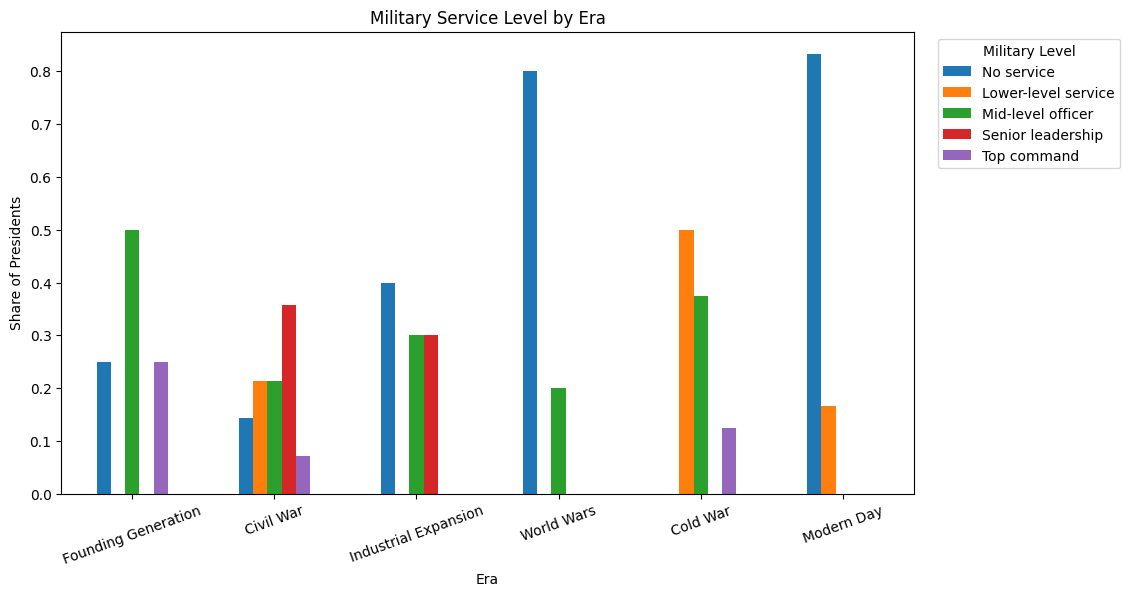

In [34]:
mil_by_era = pd.crosstab(df["era"], df["military_level"])
mil_by_era_pct = mil_by_era.div(mil_by_era.sum(axis=1), axis=0)

mil_by_era_pct[order].plot(kind="bar", figsize=(11, 6))
plt.title("Military Service Level by Era")
plt.xlabel("Era")
plt.ylabel("Share of Presidents")
plt.xticks(rotation=20)
plt.legend(title="Military Level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

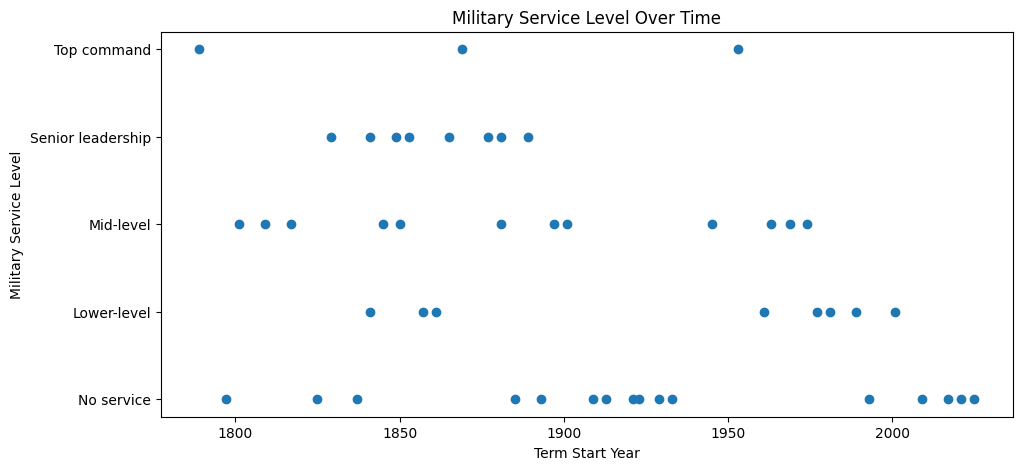

In [35]:
level_to_num = {
    "No service": 0,
    "Lower-level service": 1,
    "Mid-level officer": 2,
    "Senior leadership": 3,
    "Top command": 4
}

df["military_level_num"] = df["military_level"].map(level_to_num)

plt.figure(figsize=(11, 5))
plt.scatter(df["term_start"], df["military_level_num"])
plt.yticks(
    [0, 1, 2, 3, 4],
    ["No service", "Lower-level", "Mid-level", "Senior leadership", "Top command"]
)
plt.title("Military Service Level Over Time")
plt.xlabel("Term Start Year")
plt.ylabel("Military Service Level")
plt.show()

In [44]:
# since all presidents had multiple jobs, this table is **one row per job**

occ_long = (
    df[["Name", "Occupation", "term_start", "Party", "era"]]
    .assign(occupation_split=lambda x: x["Occupation"].fillna("").str.split(r"\s*,\s*"))
    .explode("occupation_split")
    .rename(columns={"occupation_split": "occupation_individual"})
)

occ_long["occupation_individual"] = occ_long["occupation_individual"].str.strip()
occ_long = occ_long[occ_long["occupation_individual"] != ""].copy()

occ_long.head(20)

,Name,Occupation,term_start,Party,era,occupation_individual
0,George Washington,"Plantation Owner, Soldier",1789,"None, Federalist",Founding Generation,Plantation Owner
0,George Washington,"Plantation Owner, Soldier",1789,"None, Federalist",Founding Generation,Soldier
1,John Adams,"Lawyer, Farmer",1797,Federalist,Founding Generation,Lawyer
1,John Adams,"Lawyer, Farmer",1797,Federalist,Founding Generation,Farmer
2,Thomas Jefferson,"Inventor,Lawyer, Architect",1801,Democratic-Republican,Founding Generation,Inventor
2,Thomas Jefferson,"Inventor,Lawyer, Architect",1801,Democratic-Republican,Founding Generation,Lawyer
2,Thomas Jefferson,"Inventor,Lawyer, Architect",1801,Democratic-Republican,Founding Generation,Architect
3,James Madison,"Plantation Owner, Lawyer",1809,Democratic-Republican,Founding Generation,Plantation Owner
3,James Madison,"Plantation Owner, Lawyer",1809,Democratic-Republican,Founding Generation,Lawyer
4,James Monroe,"Plantation Owner, Lawyer",1817,Democratic-Republican,Civil War,Plantation Owner


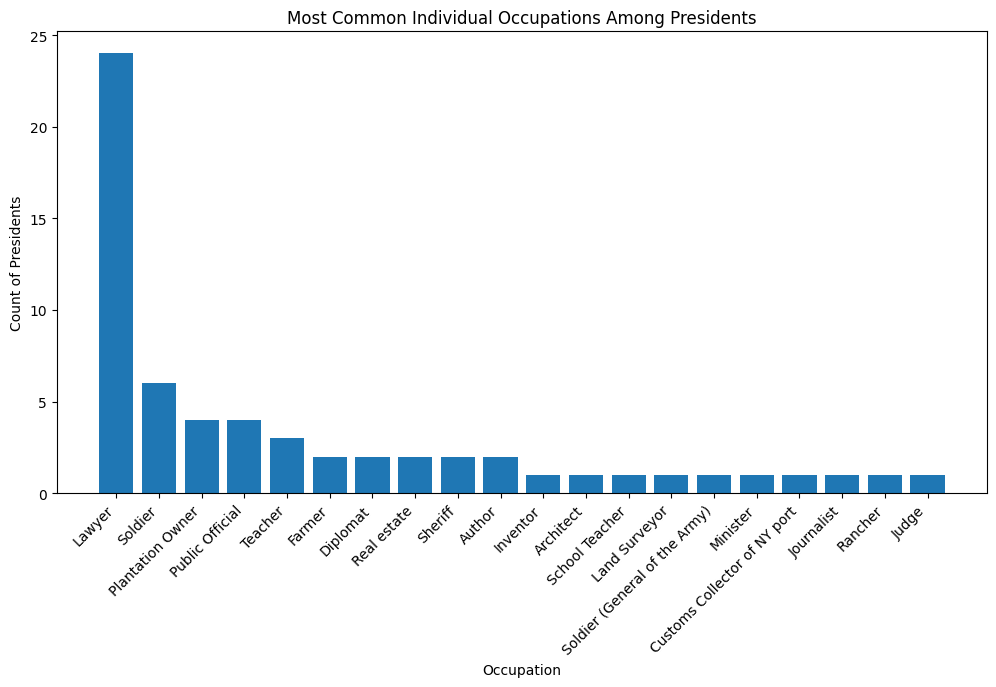

,count
occupation_individual,
Lawyer,24
Soldier,6
Plantation Owner,4
Public Official,4
Teacher,3
Farmer,2
Diplomat,2
Real estate,2
Sheriff,2


In [45]:
occ_counts = occ_long["occupation_individual"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(occ_counts.head(20).index, occ_counts.head(20).values)
plt.title("Most Common Individual Occupations Among Presidents")
plt.xlabel("Occupation")
plt.ylabel("Count of Presidents")
plt.xticks(rotation=45, ha="right")
plt.show()

occ_counts

In [46]:
# broad grouping dictionary
occupation_group_map = {
    # law / legal
    "Lawyer": "Law / Legal",
    "Judge": "Law / Legal",
    "Dean of Law School": "Law / Legal",
    "Law Lecturer": "Law / Legal",
    "Law Professor": "Law / Legal",

    # military
    "Soldier": "Military",
    "Soldier (General of the Army)": "Military",
    "General": "Military",
    "U.S. Navy Officer": "Military",
    "Navy Officer": "Military",

    # government / public service
    "Public Official": "Government / Public Service",
    "Diplomat": "Government / Public Service",
    "Sheriff": "Government / Public Service",
    "Customs Collector of NY port": "Government / Public Service",

    # education / academia / religion
    "Teacher": "Education / Academia",
    "School Teacher": "Education / Academia",
    "Professor": "Education / Academia",
    "Political scientist": "Education / Academia",
    "Minister": "Religion",

    # agriculture / land
    "Farmer": "Agriculture / Land",
    "Peanut Farmer": "Agriculture / Land",
    "Plantation Owner": "Agriculture / Land",
    "Rancher": "Agriculture / Land",
    "Land Surveyor": "Agriculture / Land",

    # business / finance / real estate
    "Real estate": "Business / Finance",
    "Banker": "Business / Finance",
    "Businessman (Oil)": "Business / Finance",
    "Businessman (Oil": "Business / Finance",   # in case the text got split oddly
    "Men'S Clothing Retailer": "Business / Finance",

    # media / writing / publishing
    "Author": "Media / Writing",
    "Journalist": "Media / Writing",
    "Newspaper Publisher/Editor": "Media / Writing",
    "Actor": "Media / Writing",

    # technical / professional
    "Inventor": "Technical / Professional",
    "Architect": "Technical / Professional",
    "Engineer": "Technical / Professional",

    # labor / trades
    "Tailor": "Trades / Labor",
    "Union leaser": "Trades / Labor",  # maybe typo for union leader
}

# apply to dataframe
occ_long["occupation_group"] = occ_long["occupation_individual"].map(occupation_group_map)

# anything not matched goes to Other / Unknown
occ_long["occupation_group"] = occ_long["occupation_group"].fillna("Other / Unknown")

In [40]:
occ_long = occ_long[occ_long["occupation_individual"] != "Baseball)"]

In [ ]:
occ_long

,Name,Occupation,term_start,Party,occupation_individual,occupation_group
0,George Washington,"Plantation Owner, Soldier",1789,"None, Federalist",Plantation Owner,Agriculture / Land
0,George Washington,"Plantation Owner, Soldier",1789,"None, Federalist",Soldier,Military
1,John Adams,"Lawyer, Farmer",1797,Federalist,Lawyer,Law / Legal
1,John Adams,"Lawyer, Farmer",1797,Federalist,Farmer,Agriculture / Land
2,Thomas Jefferson,"Inventor,Lawyer, Architect",1801,Democratic-Republican,Inventor,Technical / Professional
...,...,...,...,...,...,...
42,George W. Bush,"Businessman (Oil, Baseball)",2001,Republican,Businessman (Oil,Business / Finance
43,Barack Obama,Law Professor,2009,Democratic,Law Professor,Law / Legal
44,Donald Trump,Real estate,2017,Republican,Real estate,Business / Finance
45,Joe Biden,Lawyer,2021,Democratic,Lawyer,Law / Legal


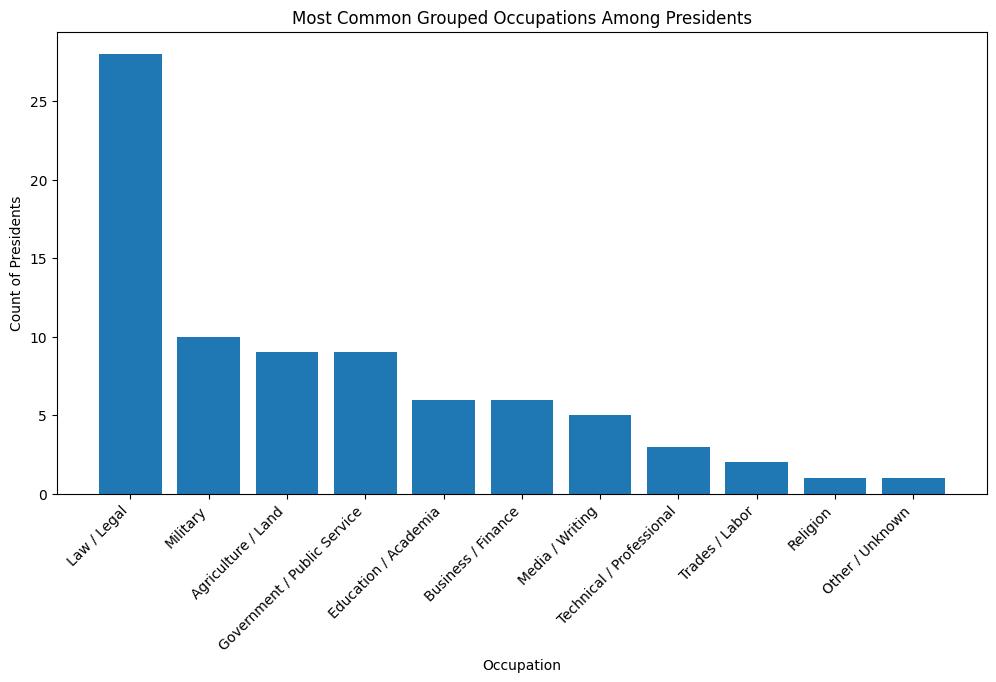

In [47]:
occ_counts = occ_long["occupation_group"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(occ_counts.head(20).index, occ_counts.head(20).values)
plt.title("Most Common Grouped Occupations Among Presidents")
plt.xlabel("Occupation")
plt.ylabel("Count of Presidents")
plt.xticks(rotation=45, ha="right")
plt.show()

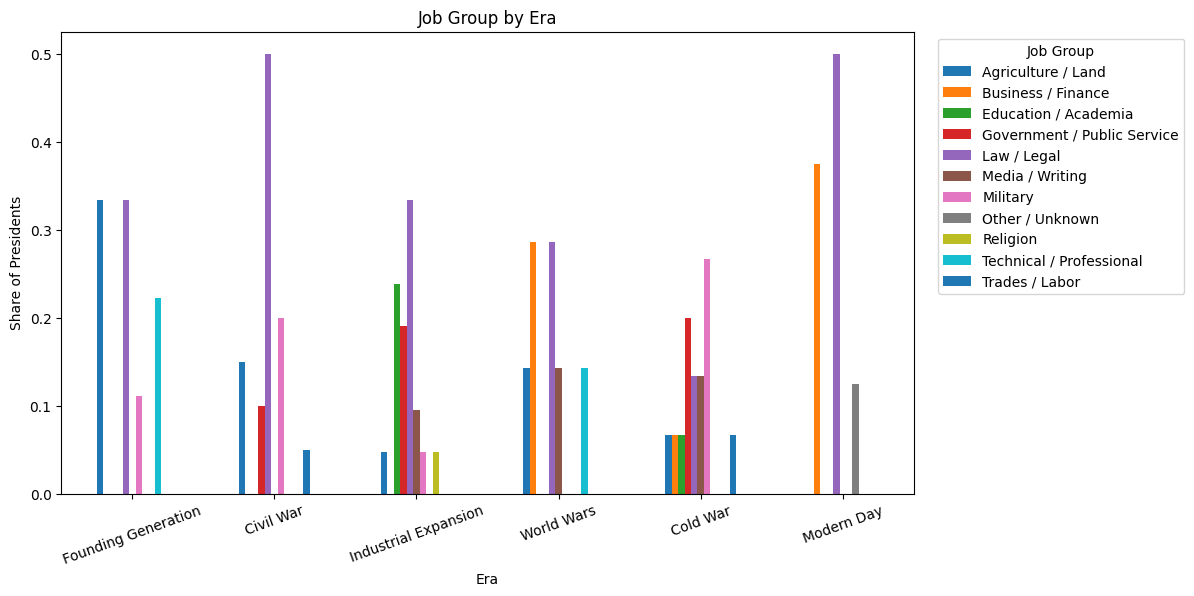

In [50]:
job_by_era = pd.crosstab(occ_long["era"], occ_long["occupation_group"])
job_by_era_pct = job_by_era.div(job_by_era.sum(axis=1), axis=0)

job_by_era_pct.plot(kind="bar", figsize=(11, 6))
plt.title("Job Group by Era")
plt.xlabel("Era")
plt.ylabel("Share of Presidents")
plt.xticks(rotation=20)
plt.legend(title="Job Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

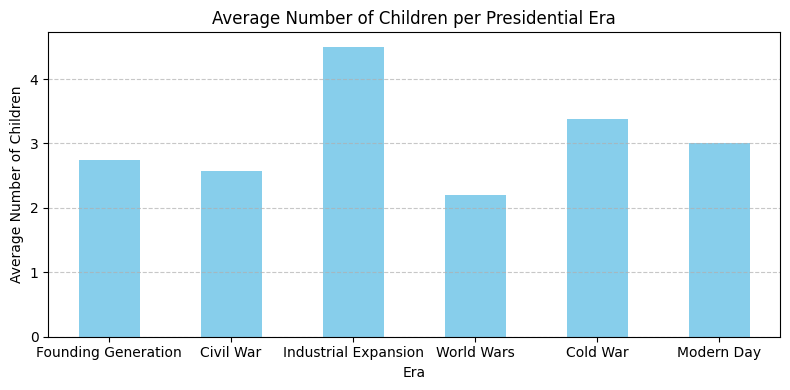

In [59]:
# average number of children in each era
average_children_by_era = df.groupby('era', observed=True)['Children'].mean()

plt.figure(figsize=(8, 4))
average_children_by_era.plot(kind='bar', color='skyblue')
plt.title('Average Number of Children per Presidential Era')
plt.xlabel('Era')
plt.ylabel('Average Number of Children')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

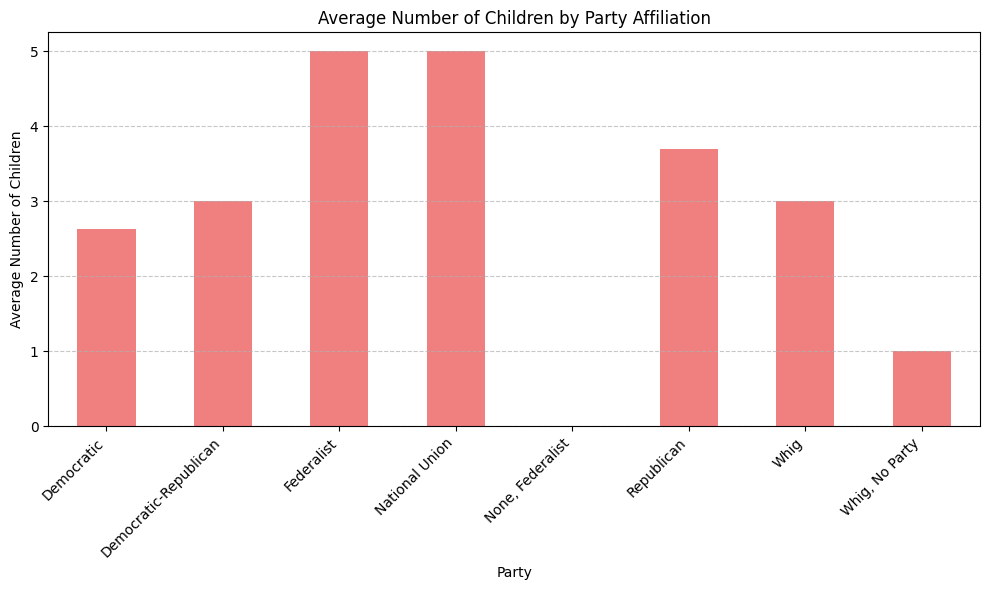

In [60]:
# number of children vs. party affiliation EDA
plt.figure(figsize=(10, 6))
df.groupby('Party', observed=True)['Children'].mean().plot(kind='bar', color='lightcoral')
plt.title('Average Number of Children by Party Affiliation')
plt.xlabel('Party')
plt.ylabel('Average Number of Children')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

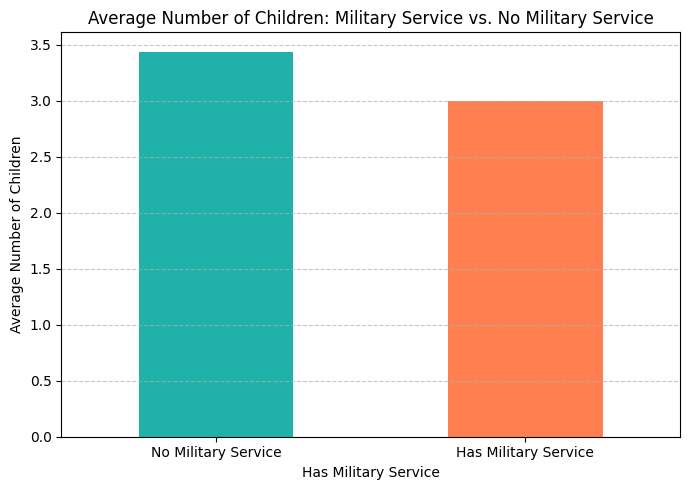

In [61]:
avg_children_by_military = df.groupby('has_military_service')['Children'].mean()

plt.figure(figsize=(7, 5))
avg_children_by_military.plot(kind='bar', color=['lightseagreen', 'coral'])
plt.title('Average Number of Children: Military Service vs. No Military Service')
plt.xlabel('Has Military Service')
plt.ylabel('Average Number of Children')
plt.xticks(ticks=[0, 1], labels=['No Military Service', 'Has Military Service'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [70]:
# The 'executive_orders' DataFrame was already loaded without a header,
# so the columns are currently integer-indexed (0 and 1).

# Rename columns 0 and 1 to 'Name' and 'Executive Orders Count'
executive_orders.columns = ['Name', 'Executive Orders Count']

# Convert 'Executive Orders Count' to numeric, handling commas and potential errors
executive_orders['Executive Orders Count'] = (
    executive_orders['Executive Orders Count']
    .astype(str) # Ensure it's string before calling .str.replace
    .str.replace(',', '', regex=False) # Remove commas from the string
    .apply(lambda x: pd.to_numeric(x, errors='coerce')) # Convert to numeric
)

# Clean the 'Name' column by removing 'Pres.' and stripping whitespace
executive_orders['Name'] = executive_orders['Name'].str.replace('Pres.', '', regex=False).str.strip()

executive_orders.head()

,Name,Executive Orders Count
1,Woodrow Wilson,1803
2,Calvin Coolidge,1203
3,Theodore Roosevelt,1081
4,Herbert Hoover,968
5,Harry S. Truman,907


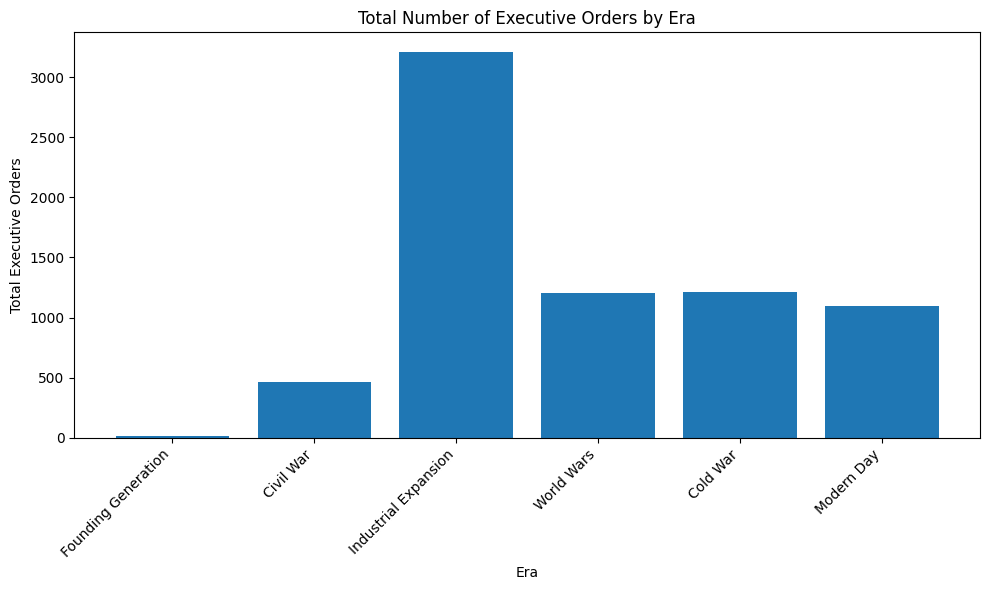

                    era  Executive Orders Count
0   Founding Generation                    14.0
1             Civil War                   463.0
2  Industrial Expansion                  3212.0
3            World Wars                  1203.0
4              Cold War                  1213.0
5            Modern Day                  1093.0


In [71]:
pres_executive_orders = pd.merge(
    df[['Name', 'era', 'term_start']], executive_orders, on='Name', how='left'
)

executive_orders_by_era = pres_executive_orders.groupby('era', observed=True)['Executive Orders Count'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(executive_orders_by_era['era'].astype(str), executive_orders_by_era['Executive Orders Count'])
plt.title('Total Number of Executive Orders by Era')
plt.xlabel('Era')
plt.ylabel('Total Executive Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(executive_orders_by_era)